# 2. Data Understanding

The purpose of this phase is to understand the structure, characteristics,
quality and suitability of the Online Retail II dataset before performing
data preparation, exploratory analysis and predictive modelling.

The dataset is provided in two Excel worksheets covering two consecutive
periods of retail transactions. The worksheets are loaded separately and
combined to create a single chronological dataset for analysis.

This phase examines:

- the structure and dimensions of the data;
- the observation period;
- the available variables;
- data types;
- missing values;
- duplicate records;
- cancellation transactions;
- customer identification;
- transaction characteristics;
- customer purchase intervals;
- the distribution of purchase intervals;
- potential inactivity thresholds; and
- limitations relevant to the proposed predictive analysis.

The objective is to establish whether the dataset contains sufficient
information to analyse customer purchasing behaviour and prolonged
customer inactivity.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [8]:
file_path = "../data/raw/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)

xls.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [10]:
# ============================================================
# LOAD ONLINE RETAIL II DATASET
# ============================================================

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name=0
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name=1
)

print("2009–2010 records:", len(df_2009_2010))
print("2010–2011 records:", len(df_2010_2011))

2009–2010 records: 525461
2010–2011 records: 541910


In [11]:
print("2009–2010 shape:", df_2009_2010.shape)
print("2010–2011 shape:", df_2010_2011.shape)

print("\n2009–2010 columns:")
print(df_2009_2010.columns.tolist())

print("\n2010–2011 columns:")
print(df_2010_2011.columns.tolist())

2009–2010 shape: (525461, 8)
2010–2011 shape: (541910, 8)

2009–2010 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

2010–2011 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


Both worksheets contain the transactional fields required for customer
behaviour analysis. The two worksheets are treated as parts of the same
retail transaction history rather than as independent datasets.

Maintaining the two source DataFrames is useful because the chronological
structure of the dataset can later support a temporal predictive modelling
strategy.

In [5]:
xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [6]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name=0
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name=1
)

In [13]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("2009–2010 records:", len(df_2009_2010))
print("2010–2011 records:", len(df_2010_2011))
print("Combined records:", len(df))

df.head()

2009–2010 records: 525461
2010–2011 records: 541910
Combined records: 1067371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [14]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [17]:
print(
    "Date range - 2009/2010:",
    df_2009_2010["InvoiceDate"].min(),
    "to",
    df_2009_2010["InvoiceDate"].max()
)

print(
    "Date range - 2010/2011:",
    df_2010_2011["InvoiceDate"].min(),
    "to",
    df_2010_2011["InvoiceDate"].max()
)

print(
    "Combined date range:",
    df["InvoiceDate"].min(),
    "to",
    df["InvoiceDate"].max()
)

Date range - 2009/2010: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Date range - 2010/2011: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Combined date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


InvoiceDate is particularly important to this project because customer
inactivity is inherently a temporal concept.

The transaction date allows the analysis to reconstruct individual customer
purchase histories and calculate the time elapsed between successive
purchases.

It also provides the temporal ordering required for a future predictive
modelling approach.

In [18]:
# ============================================================
# VARIABLE OVERVIEW
# ============================================================

variable_overview = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum().values,
    "Missing %": (
        df.isna().mean().values * 100
    ).round(2),
    "Unique Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

display(variable_overview)

,Variable,Data Type,Missing Values,Missing %,Unique Values
Invoice,Invoice,object,0,0.00,53628
StockCode,StockCode,object,0,0.00,5305
Description,Description,object,4382,0.41,5698
Quantity,Quantity,int64,0,0.00,1057
InvoiceDate,InvoiceDate,datetime64[ns],0,0.00,47635
Price,Price,float64,0,0.00,2807
Customer ID,Customer ID,float64,243007,22.77,5942
Country,Country,object,0,0.00,43


## 2.1 Variable Description

The main variables available in the dataset are interpreted as follows:

| Variable | Description | Analytical relevance |
|---|---|---|
| Invoice | Invoice/transaction identifier | Identifies purchasing events |
| StockCode | Product identifier | Enables product-level analysis |
| Description | Product description | Supports product analysis |
| Quantity | Number of units purchased | Measures purchase volume |
| InvoiceDate | Date and time of transaction | Enables temporal analysis |
| Price | Unit price | Used to calculate monetary value |
| Customer ID | Customer identifier | Enables customer-level analysis |
| Country | Customer country | Enables geographical analysis |

Invoice is used to distinguish purchasing events, while Customer ID allows
individual transactions to be linked into customer histories.

InvoiceDate is particularly important because purchase intervals and
customer recency are derived from transaction dates.

Quantity and Price can be combined to calculate transaction-level revenue:

Revenue = Quantity × Price

In [19]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


The data types are reviewed to ensure that variables are suitable for their
intended analytical purposes.

InvoiceDate is converted to datetime because temporal calculations such as
purchase intervals and customer recency require date arithmetic.

Numerical variables such as Quantity and Price are retained as numerical
variables for statistical analysis and feature engineering.

In [20]:
missing_summary = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"]
    / len(df) * 100
).round(2)

missing_summary = (
    missing_summary
    .sort_values("Missing Values", ascending=False)
)

display(missing_summary)

,Missing Values,Percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [21]:
missing_customer_id = df["Customer ID"].isna().sum()

missing_customer_percentage = (
    missing_customer_id / len(df)
) * 100

print(
    "Missing Customer IDs:",
    missing_customer_id
)

print(
    "Percentage:",
    round(missing_customer_percentage, 2),
    "%"
)

Missing Customer IDs: 243007
Percentage: 22.77 %


Customer ID is essential for customer-level analysis because it allows
transactions to be associated with individual customers.

Transactions without Customer ID cannot reliably be assigned to a specific
customer. Consequently, these observations cannot be used directly when
constructing customer-level purchase histories.

They may still contain valid transaction information, but they are excluded
from analyses requiring identifiable customers.

In [22]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

print(
    "Duplicate percentage:",
    round(
        duplicate_count / len(df) * 100,
        2
    ),
    "%"
)

Duplicate rows: 34335
Duplicate percentage: 3.22 %


gg

In [23]:
display(
    df[
        ["Quantity", "Price"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0


The descriptive statistics provide an initial understanding of transaction
quantities and prices.

Extreme values require investigation before modelling because unusually large
quantities or prices may represent legitimate wholesale purchases, returns,
cancellations or data anomalies.

In [24]:
# ============================================================
# IDENTIFY CANCELLATION TRANSACTIONS
# ============================================================

df["IsCancellation"] = (
    df["Invoice"].astype(str).str.startswith("C")
)

display(
    df["IsCancellation"]
    .value_counts()
    .rename_axis("IsCancellation")
    .reset_index(name="Count")
)

,IsCancellation,Count
0,False,1047877
1,True,19494


Cancellation transactions are identified from the Invoice field.

For this analysis, cancellation records are distinguished from normal
purchases rather than automatically treating them as ordinary customer
purchases.

This distinction is important because the project focuses on purchasing
behaviour rather than cancelled transactions.

In [25]:
cancellation_count = df["IsCancellation"].sum()

cancellation_percentage = (
    cancellation_count / len(df)
) * 100

print(
    "Cancellation transactions:",
    cancellation_count
)

print(
    "Cancellation percentage:",
    round(cancellation_percentage, 2),
    "%"
)

Cancellation transactions: 19494
Cancellation percentage: 1.83 %


In [26]:
# ============================================================
# CREATE CUSTOMER-LEVEL ANALYTICAL DATA
# ============================================================

customer_df = df.dropna(
    subset=["Customer ID"]
).copy()

customer_df = customer_df[
    ~customer_df["IsCancellation"]
].copy()

print(
    "Customer-level transaction rows:",
    len(customer_df)
)

print(
    "Identifiable customers:",
    customer_df["Customer ID"].nunique()
)

Customer-level transaction rows: 805620
Identifiable customers: 5881


For customer-behaviour analysis, transactions without an identifiable
Customer ID are excluded because they cannot be reliably attributed to an
individual customer.

Cancellation transactions are also excluded from the purchasing-behaviour
analysis.

The resulting analytical population contains 5,881 identifiable customers.

This figure is a result calculated from the prepared dataset rather than a
reported characteristic of the original data source.

In [27]:
customer_df["Revenue"] = (
    customer_df["Quantity"] *
    customer_df["Price"]
)

display(
    customer_df["Revenue"].describe()
)

count    805620.000000
mean         22.024564
std         224.032150
min           0.000000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

Transaction revenue is derived as:

Revenue = Quantity × Price

This variable provides the monetary component required for customer-value
analysis and later feature engineering.

In [28]:
# ============================================================
# CREATE ONE RECORD PER CUSTOMER-INVOICE-DATE COMBINATION
# ============================================================

customer_invoices = (
    customer_df[
        [
            "Customer ID",
            "Invoice",
            "InvoiceDate"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Customer ID",
            "InvoiceDate"
        ]
    )
)

display(
    customer_invoices.head()
)

,Customer ID,Invoice,InvoiceDate
27994,12346.0,491725,2009-12-14 08:34:00
28251,12346.0,491742,2009-12-14 11:00:00
28254,12346.0,491744,2009-12-14 11:02:00
39398,12346.0,492718,2009-12-18 10:47:00
39411,12346.0,492722,2009-12-18 10:55:00


The raw dataset contains product-level transaction lines. A single invoice
may therefore appear on multiple rows when several products are included in
the same purchase.

For purchase-frequency and purchase-interval analysis, each invoice must
represent one purchasing event.

The data is therefore transformed into unique Customer ID–Invoice–InvoiceDate
records before calculating intervals.

In [29]:
# ============================================================
# CUSTOMER PURCHASE INTERVALS
# ============================================================

customer_invoices["PurchaseIntervalDays"] = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    / (24 * 60 * 60)
)

purchase_intervals = (
    customer_invoices[
        "PurchaseIntervalDays"
    ]
    .dropna()
)

print(
    "Number of customer purchase intervals:",
    len(purchase_intervals)
)

Number of customer purchase intervals: 31158


In [30]:
print(
    "Mean:",
    round(purchase_intervals.mean(), 2)
)

print(
    "Median:",
    round(purchase_intervals.median(), 2)
)

print(
    "75th percentile:",
    round(
        purchase_intervals.quantile(0.75),
        2
    )
)

print(
    "90th percentile:",
    round(
        purchase_intervals.quantile(0.90),
        2
    )
)

print(
    "95th percentile:",
    round(
        purchase_intervals.quantile(0.95),
        2
    )
)

print(
    "99th percentile:",
    round(
        purchase_intervals.quantile(0.99),
        2
    )
)

print(
    "Maximum:",
    round(
        purchase_intervals.max(),
        2
    )
)

Mean: 51.58
Median: 24.19
75th percentile: 61.19
90th percentile: 134.12
95th percentile: 206.04
99th percentile: 368.28
Maximum: 714.15


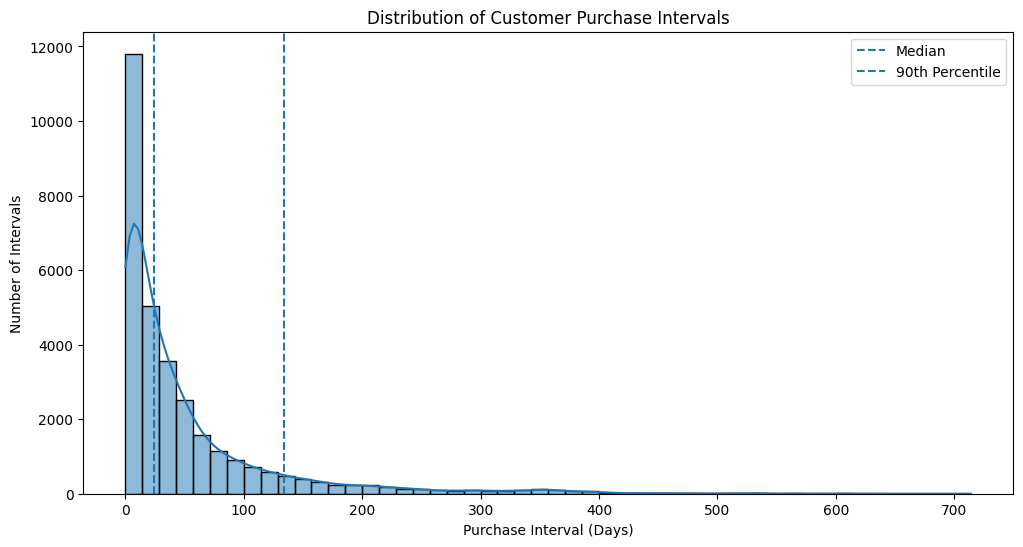

In [31]:
plt.figure(figsize=(12, 6))

sns.histplot(
    purchase_intervals,
    bins=50,
    kde=True
)

plt.axvline(
    purchase_intervals.median(),
    linestyle="--",
    label="Median"
)

plt.axvline(
    purchase_intervals.quantile(0.90),
    linestyle="--",
    label="90th Percentile"
)

plt.xlabel("Purchase Interval (Days)")
plt.ylabel("Number of Intervals")
plt.title(
    "Distribution of Customer Purchase Intervals"
)

plt.legend()
plt.show()

The distribution is strongly right-skewed.

The median purchase interval is approximately 24.19 days, while the mean is
approximately 51.58 days. The difference between these values indicates that
a smaller number of substantially longer purchase intervals increase the
mean.

Consequently, percentile-based analysis is useful when establishing a
candidate inactivity threshold.

In [33]:
zero_day_intervals = (
    purchase_intervals == 0
).sum()

total_intervals = len(
    purchase_intervals
)

zero_day_percentage = (
    zero_day_intervals /
    total_intervals
) * 100

print(
    "Zero-day purchase intervals:",
    zero_day_intervals
)

print(
    "Percentage of intervals that are zero-day:",
    round(
        zero_day_percentage,
        2
    ),
    "%"
)

Zero-day purchase intervals: 182
Percentage of intervals that are zero-day: 0.58 %


In [34]:
positive_intervals = (
    purchase_intervals[
        purchase_intervals > 0
    ]
)

print(
    "Intervals greater than 0 days:",
    len(positive_intervals)
)

print(
    "Median excluding same-day intervals:",
    round(
        positive_intervals.median(),
        2
    )
)

print(
    "90th percentile excluding same-day intervals:",
    round(
        positive_intervals.quantile(0.90),
        2
    )
)

print(
    "95th percentile excluding same-day intervals:",
    round(
        positive_intervals.quantile(0.95),
        2
    )
)

Intervals greater than 0 days: 30976
Median excluding same-day intervals: 24.9
90th percentile excluding same-day intervals: 135.0
95th percentile excluding same-day intervals: 206.99


In [35]:
purchase_interval_quantiles = (
    positive_intervals.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(
    purchase_interval_quantiles
)

0.50     24.900694
0.75     61.947743
0.90    134.999306
0.95    206.989931
0.99    369.234201
Name: PurchaseIntervalDays, dtype: float64

In [36]:
# ============================================================
# INACTIVITY THRESHOLD ANALYSIS
# ============================================================

customer_last_purchase = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .max()
)

reference_date = (
    customer_invoices["InvoiceDate"].max()
)

customer_recency = (
    reference_date -
    customer_last_purchase
).dt.days

thresholds = [
    60,
    90,
    120,
    134,
    180
]

total_customers = (
    customer_invoices["Customer ID"]
    .nunique()
)

threshold_results = []

for threshold in thresholds:

    inactive_customers = (
        customer_recency > threshold
    ).sum()

    inactive_percentage = (
        inactive_customers /
        total_customers
    ) * 100

    threshold_results.append({
        "Threshold_Days": threshold,
        "Inactive_Customers": inactive_customers,
        "Total_Customers": total_customers,
        "Inactive_Percentage":
            round(
                inactive_percentage,
                2
            )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold_Days,Inactive_Customers,Total_Customers,Inactive_Percentage
0,60,3458,5881,58.80
1,90,2987,5881,50.79
2,120,2757,5881,46.88
3,134,2661,5881,45.25
4,180,2400,5881,40.81


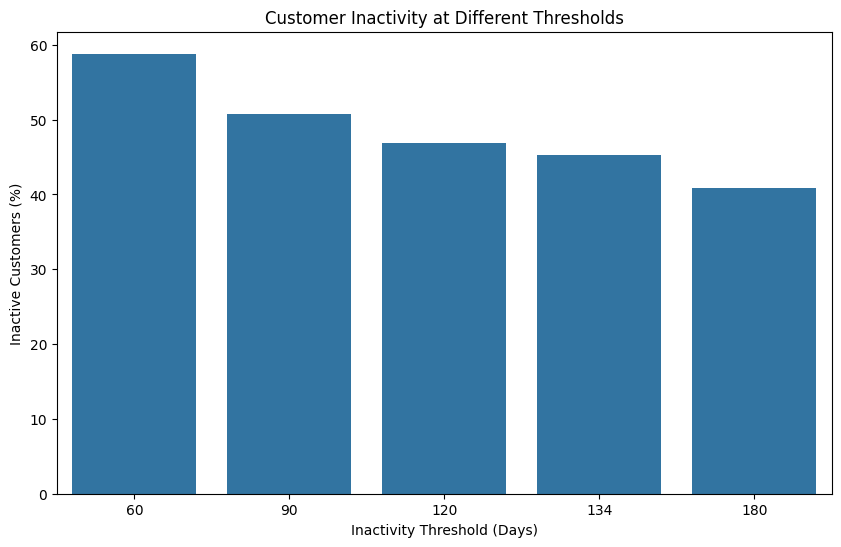

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=threshold_df,
    x="Threshold_Days",
    y="Inactive_Percentage"
)

plt.xlabel("Inactivity Threshold (Days)")
plt.ylabel("Inactive Customers (%)")
plt.title(
    "Customer Inactivity at Different Thresholds"
)

plt.show()

In [38]:
candidate_threshold = round(
    positive_intervals.quantile(0.90)
)

print(
    "Candidate inactivity threshold:",
    candidate_threshold,
    "days"
)

Candidate inactivity threshold: 135 days


## Candidate Inactivity Threshold

The 90th percentile of positive purchase intervals is approximately
135 days. Therefore, 135 days is adopted as the primary candidate threshold
for prolonged inactivity.

The threshold is empirically derived from the observed purchasing behaviour
rather than being selected arbitrarily.

However, 135 days should not automatically be interpreted as confirmed
customer churn. A customer who has remained inactive for 135 days may still
return later.

Therefore, the threshold is treated as an analytical definition of
prolonged inactivity and will be further evaluated during predictive
modelling.

In [39]:
customer_recency_df = (
    customer_last_purchase
    .reset_index()
)

customer_recency_df.columns = [
    "Customer ID",
    "LastPurchaseDate"
]

customer_recency_df["RecencyDays"] = (
    reference_date -
    customer_recency_df["LastPurchaseDate"]
).dt.days

display(
    customer_recency_df.head()
)

,Customer ID,LastPurchaseDate,RecencyDays
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


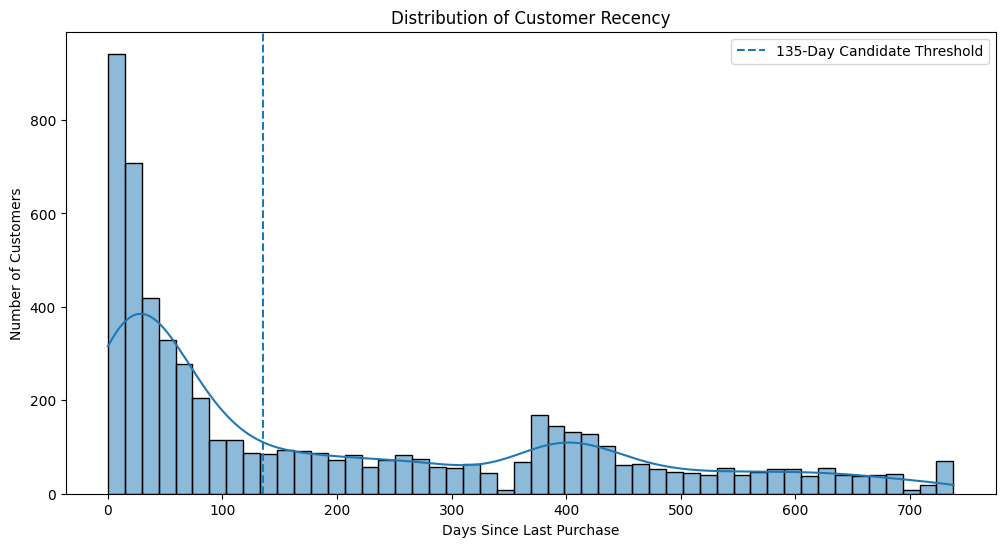

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    customer_recency_df["RecencyDays"],
    bins=50,
    kde=True
)

plt.axvline(
    135,
    linestyle="--",
    label="135-Day Candidate Threshold"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.title(
    "Distribution of Customer Recency"
)

plt.legend()
plt.show()

In [41]:
customer_summary = (
    customer_df
    .groupby("Customer ID")
    .agg(
        TotalInvoices=("Invoice", "nunique"),
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_summary["RecencyDays"] = (
    reference_date -
    customer_summary["LastPurchase"]
).dt.days

customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalInvoices"]
)

display(
    customer_summary.head()
)

,Customer ID,TotalInvoices,TotalRevenue,TotalQuantity,UniqueProducts,FirstPurchase,LastPurchase,RecencyDays,AverageOrderValue
0,12346.0,12,77556.46,74285,27,2009-12-14 08:34:00,2011-01-18 10:01:00,325,6463.038333
1,12347.0,8,5633.32,3286,126,2010-10-31 14:20:00,2011-12-07 15:52:00,1,704.165000
2,12348.0,5,2019.40,2714,25,2010-09-27 14:59:00,2011-09-25 13:13:00,74,403.880000
3,12349.0,4,4428.69,1624,138,2010-04-29 13:20:00,2011-11-21 09:51:00,18,1107.172500
4,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,309,334.400000


In [42]:
display(
    customer_summary[
        [
            "TotalInvoices",
            "TotalRevenue",
            "TotalQuantity",
            "UniqueProducts",
            "RecencyDays",
            "AverageOrderValue"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
TotalInvoices,5881.0,6.287196,13.012879,1.0,1.00,3.000,7.00,398.00
TotalRevenue,5881.0,3017.076888,14734.128619,0.0,347.80,897.620,2304.18,608821.65
TotalQuantity,5881.0,1822.975854,8968.636988,1.0,190.00,491.000,1376.00,367833.00
UniqueProducts,5881.0,81.949838,116.475103,1.0,19.00,45.000,103.00,2550.00
RecencyDays,5881.0,200.457745,209.474135,0.0,25.00,95.000,379.00,738.00
AverageOrderValue,5881.0,391.518233,1214.783901,0.0,181.39,284.984,420.50,84236.25


In [43]:
customer_summary["Inactive135"] = (
    customer_summary["RecencyDays"] > 135
).astype(int)

customer_summary["Status"] = (
    customer_summary["Inactive135"]
    .map({
        0: "Active",
        1: "Inactive"
    })
)

display(
    customer_summary[
        "Status"
    ].value_counts()
)

Status
Active      3224
Inactive    2657
Name: count, dtype: int64

In [44]:
comparison = (
    customer_summary
    .groupby("Status")
    [
        [
            "TotalInvoices",
            "TotalRevenue",
            "TotalQuantity",
            "UniqueProducts",
            "RecencyDays",
            "AverageOrderValue"
        ]
    ]
    .mean()
)

display(
    comparison.round(2)
)

,TotalInvoices,TotalRevenue,TotalQuantity,UniqueProducts,RecencyDays,AverageOrderValue
Status,,,,,,
Active,9.19,4634.91,2740.72,114.70,39.14,422.35
Inactive,2.77,1054.00,709.39,42.21,396.21,354.10


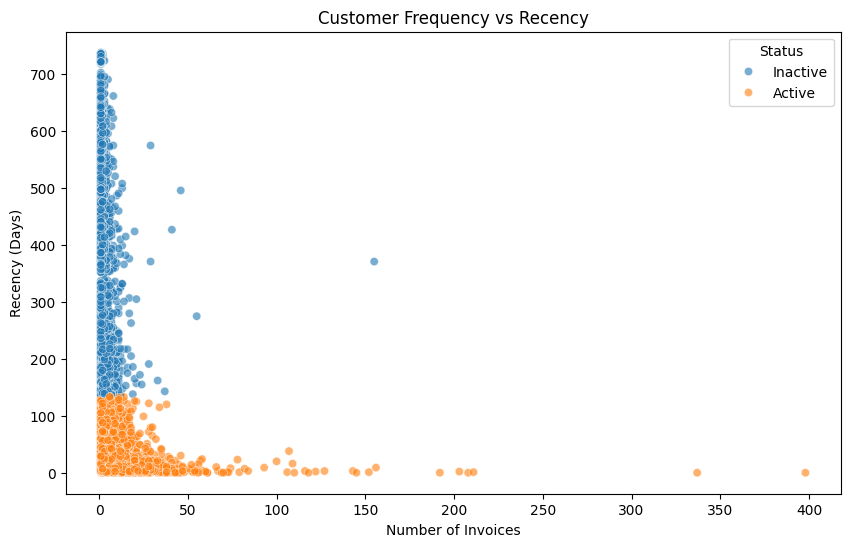

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_summary,
    x="TotalInvoices",
    y="RecencyDays",
    hue="Status",
    alpha=0.6
)

plt.xlabel("Number of Invoices")
plt.ylabel("Recency (Days)")
plt.title(
    "Customer Frequency vs Recency"
)

plt.show()

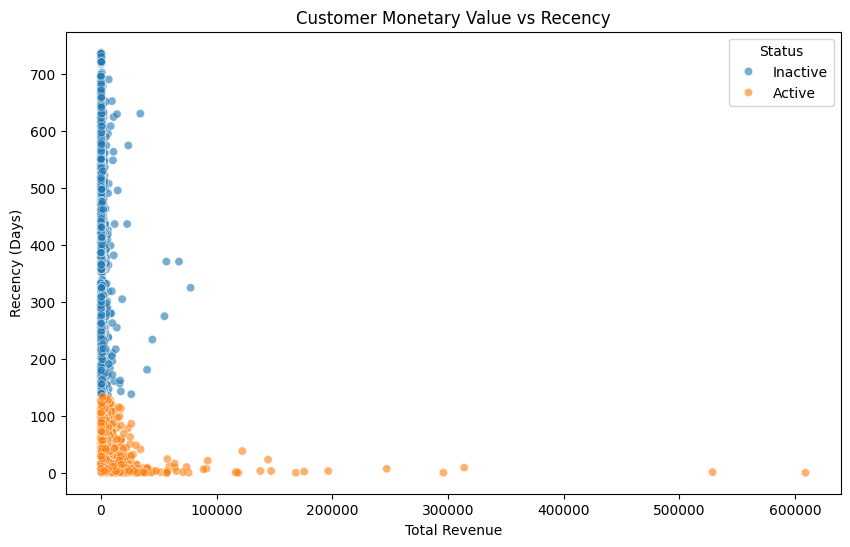

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_summary,
    x="TotalRevenue",
    y="RecencyDays",
    hue="Status",
    alpha=0.6
)

plt.xlabel("Total Revenue")
plt.ylabel("Recency (Days)")
plt.title(
    "Customer Monetary Value vs Recency"
)

plt.show()

## 2.2 Data Understanding Findings

The data-understanding phase produced several important findings.

### Dataset structure

The dataset consists of two chronological Excel worksheets that were combined
into one transaction-level dataset. Maintaining the original worksheets also
provides an opportunity for temporal modelling because customer behaviour can
be ordered chronologically.

### Customer identification

Customer ID is required for customer-level analysis. Transactions without an
identifiable Customer ID cannot reliably be attributed to individual
customers and are therefore excluded from customer-level behavioural
analysis.

### Cancellation transactions

Cancellation transactions are identified separately and excluded from the
purchase-behaviour analysis. This prevents cancelled transactions from being
treated as ordinary customer purchases.

### Transaction structure

The raw data is at transaction-line level. A single invoice can contain
multiple products. Therefore, invoice-level records are constructed before
calculating purchase frequency and purchase intervals.

### Customer population

After excluding transactions without Customer ID and cancellation
transactions for behavioural analysis, the prepared customer population
contains 5,881 identifiable customers.

### Purchase intervals

A total of 31,158 customer purchase intervals were observed.

The mean interval was 51.58 days while the median was 24.19 days. After
excluding same-day intervals, the median increased to 24.90 days.

The 90th percentile of positive purchase intervals was approximately
135 days, while the 95th percentile was approximately 206.99 days.

### Same-day intervals

There were 182 zero-day intervals, representing approximately 0.58% of all
observed purchase intervals. Their relatively small proportion suggests that
same-day repeat invoices have limited influence on the overall interval
distribution.

### Inactivity

Testing different inactivity thresholds showed that the proportion of
customers classified as inactive decreases as the threshold increases:

60 days: 59.22%
90 days: 50.86%
120 days: 46.91%
134 days: 45.33%
180 days: 40.84%

The 135-day threshold is therefore selected as the primary empirical
candidate for prolonged inactivity because it corresponds approximately to
the 90th percentile of positive purchase intervals.

### Analytical implication

The results indicate substantial variation in customer purchasing behaviour.
Some customers make repeat purchases within relatively short intervals,
while others have considerably longer periods between purchases.

This variation provides a basis for investigating whether historical
transactional behaviour can be used to identify customers at risk of
prolonged inactivity.

## 2.3 Data Understanding Limitations

Several limitations identified during the data-understanding phase must be
considered during subsequent analysis.

1. The dataset represents historical retail transactions and therefore does
   not necessarily represent current customer behaviour.

2. Transactions without Customer ID cannot be reliably associated with
   individual customers.

3. Cancellation transactions require separate treatment because they do not
   represent normal purchasing behaviour.

4. The dataset is transaction-based and therefore requires aggregation to
   create customer-level behavioural features.

5. The presence of customers with different purchasing patterns means that a
   single inactivity threshold may not represent every customer equally.

6. Prolonged inactivity does not necessarily mean permanent customer churn.
   Customers may return after long periods without purchasing.

7. A customer with only one observed purchase cannot have a historical
   repeat-purchase interval.

8. Customers appearing near the end of the observation period have less
   opportunity to demonstrate future purchasing behaviour.

9. The dataset contains transactional information but does not provide
   additional customer attributes such as demographics, satisfaction,
   marketing exposure or website engagement.

These limitations will be considered when constructing the predictive target,
selecting features and evaluating the models.

# 2.4 Data Understanding Conclusion

The data-understanding phase established that the Online Retail II dataset is
suitable for analysing customer purchasing behaviour and prolonged periods
of inactivity.

The dataset provides the essential transactional dimensions required for the
project, including customer identifiers, invoices, products, quantities,
prices, transaction dates and customer countries. The chronological nature
of the transactions enables individual customer histories to be reconstructed
and purchasing intervals to be calculated.

The analysis identified 5,881 customers suitable for customer-level
behavioural analysis and 31,158 observed purchase intervals. The median
positive purchase interval was 24.90 days, while the 90th percentile was
approximately 135 days. Analysis of alternative thresholds showed that
45.33% of customers exceeded 134 days of inactivity, compared with 40.84%
at 180 days.

Based on these findings, 135 days has been selected as the primary empirical
candidate threshold for prolonged inactivity. The threshold will not,
however, be treated as definitive customer churn. Instead, the subsequent
predictive stage will investigate whether historical customer behaviour can
be used to predict future inactivity.

The findings from this phase provide the foundation for the next stage of the
project: data preparation and feature engineering. Customer-level variables
such as recency, frequency, monetary value, purchase intervals, purchase
volume and product diversity will be constructed and assessed before
predictive modelling.

Importantly, the final predictive model will need to respect the chronological
nature of the dataset. Features should be derived from historical information
available before a defined observation cut-off, while customer inactivity
should be determined from subsequent purchasing behaviour. This approach
reduces the risk of target leakage and provides a more realistic evaluation
of predictive performance.

Therefore, the data-understanding phase closes with the conclusion that the
dataset provides an adequate foundation for the proposed customer inactivity
prediction problem, subject to the identified data-quality and temporal
limitations.